In [8]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from arch import arch_model
import os

PROJECT_ROOT = r"C:\Users\nicol\OneDrive\Bureau\Finance"
os.chdir(PROJECT_ROOT)
print("Current working directory:", os.getcwd())



Current working directory: C:\Users\nicol\OneDrive\Bureau\Finance


In [9]:
# Charger les données test
df = pd.read_csv(
    "data/processed/features_pred.csv",
    index_col=0,
    parse_dates=True
)
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index, utc=True)

In [10]:
# Charger les mod?les ml + dl
rf_path = os.path.join(PROJECT_ROOT, "src", "models", "rf_model.pkl")
gb_path = os.path.join(PROJECT_ROOT, "src", "models", "gb_model.pkl")
lstm_path = os.path.join(PROJECT_ROOT, "src", "models", "lstm_model.keras")
gru_path = os.path.join(PROJECT_ROOT, "src", "models", "gru_model.keras")
lstm_x_scaler_path = os.path.join(PROJECT_ROOT, "src", "models", "lstm_x_scaler.pkl")
lstm_y_scaler_path = os.path.join(PROJECT_ROOT, "src", "models", "lstm_y_scaler.pkl")
gru_x_scaler_path = os.path.join(PROJECT_ROOT, "src", "models", "gru_x_scaler.pkl")
gru_y_scaler_path = os.path.join(PROJECT_ROOT, "src", "models", "gru_y_scaler.pkl")

required_paths = [
    rf_path,
    gb_path,
    lstm_path,
    gru_path,
    lstm_x_scaler_path,
    lstm_y_scaler_path,
    gru_x_scaler_path,
    gru_y_scaler_path,
]
missing_paths = [path for path in required_paths if not os.path.exists(path)]
if missing_paths:
    raise FileNotFoundError("Missing model/scaler files:\n" + "\n".join(missing_paths))

rf_model = joblib.load(rf_path)
gb_model = joblib.load(gb_path)
lstm_model = tf.keras.models.load_model(lstm_path)
gru_model = tf.keras.models.load_model(gru_path)

lstm_x_scaler = joblib.load(lstm_x_scaler_path)
lstm_y_scaler = joblib.load(lstm_y_scaler_path)
gru_x_scaler = joblib.load(gru_x_scaler_path)
gru_y_scaler = joblib.load(gru_y_scaler_path)



In [11]:
FEATURES = [
    "vol_5", "vol_10", "vol_21", "vol_ewma",
    "ATR", "RSI", "MACD", "MACD_signal",
    "log_volume", "volume_change"
]
X = df[FEATURES]
y = df["target_vol"]

In [12]:
# Pr?dictions GARCH
returns = df["log_return"].dropna()
if not isinstance(returns.index, pd.DatetimeIndex):
    returns.index = pd.to_datetime(returns.index)

garch = arch_model(returns, vol="Garch", p=1, q=1)
garch_fit = garch.fit(disp="off")
garch_forecast = garch_fit.forecast(start=returns.index[0])

# variance conditionnelle
y_pred_garch = np.sqrt(
    garch_forecast.variance.loc[X.index]
).values.flatten()
y_pred_garch = pd.Series(y_pred_garch, index=X.index)

c:\Users\nicol\OneDrive\Bureau\Finance\.venv\lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001027. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [13]:
# Prédictions ML
y_pred_rf = pd.Series(rf_model.predict(X), index=X.index)
y_pred_gb = pd.Series(gb_model.predict(X), index=X.index)

In [14]:
FEATURES_DL = [
    "vol_5", "vol_10", "vol_21", "vol_ewma",
    "log_return"
]

X_dl = df[FEATURES_DL]


def create_sequences(values, seq_length):
    # Create rolling windows like the DL training notebook.
    n_samples, n_features = values.shape
    if n_samples <= seq_length:
        return np.empty((0, seq_length, n_features))

    seqs = np.zeros((n_samples - seq_length, seq_length, n_features), dtype=values.dtype)
    for i in range(seq_length, n_samples):
        seqs[i - seq_length] = values[i - seq_length : i]
    return seqs


TIMESTEPS = 60

# Apply the same scaling used at training
X_lstm_scaled = lstm_x_scaler.transform(X_dl)
X_gru_scaled = gru_x_scaler.transform(X_dl)

seqs_lstm = create_sequences(X_lstm_scaled, TIMESTEPS)
seqs_gru = create_sequences(X_gru_scaled, TIMESTEPS)

if seqs_lstm.shape[0] == 0 or seqs_gru.shape[0] == 0:
    raise ValueError("Not enough rows to build DL sequences. Increase data or lower TIMESTEPS.")

lstm_preds_scaled = np.asarray(lstm_model.predict(seqs_lstm, verbose=0)).reshape(-1, 1)
gru_preds_scaled = np.asarray(gru_model.predict(seqs_gru, verbose=0)).reshape(-1, 1)

lstm_preds = np.clip(
    lstm_y_scaler.inverse_transform(lstm_preds_scaled).flatten(),
    1e-8,
    None,
)
gru_preds = np.clip(
    gru_y_scaler.inverse_transform(gru_preds_scaled).flatten(),
    1e-8,
    None,
)

# Align on the same index length for all models
aligned_index = y.index[TIMESTEPS:]

y = y.loc[aligned_index]
y_pred_garch = y_pred_garch.loc[aligned_index]
y_pred_rf = y_pred_rf.loc[aligned_index]
y_pred_gb = y_pred_gb.loc[aligned_index]
y_pred_lstm = pd.Series(lstm_preds, index=aligned_index)
y_pred_gru = pd.Series(gru_preds, index=aligned_index)

In [30]:
from src.evaluation.metrics import evaluate_volatility

results_ml = {
    "GARCH": evaluate_volatility(y, y_pred_garch),
    "RF": evaluate_volatility(y, y_pred_rf),
    "GB": evaluate_volatility(y, y_pred_gb),
    "LSTM": evaluate_volatility(y, y_pred_lstm),
    "GRU": evaluate_volatility(y, y_pred_gru)
}

df_results = pd.DataFrame(results_ml).T
df_results

,MSE,MAE,QLIKE
GARCH,0.000008,0.001736,-8.493160
RF,0.000003,0.000674,-8.590632
GB,0.000004,0.001084,-8.552983
LSTM,0.000004,0.000927,-8.576221
GRU,0.000004,0.001161,-8.555237


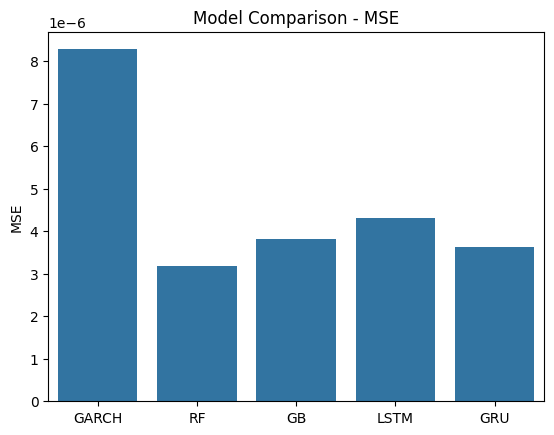

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_results, x=["GARCH", "RF", "GB", "LSTM", "GRU"], y="MSE")
plt.title("Model Comparison - MSE")
plt.show()

In [17]:
import numpy as np

def volatility_targeting(returns, predicted_vol, target_vol=0.10):

    # annualisation volatilité journalière
    predicted_vol = predicted_vol * np.sqrt(252)

    weights = target_vol / predicted_vol
    weights = np.clip(weights, 0, 3)

    strategy_returns = weights * returns

    return strategy_returns

In [18]:
strat_garch = volatility_targeting(y, y_pred_garch)
strat_rf = volatility_targeting(y, y_pred_rf)
strat_gb = volatility_targeting(y, y_pred_gb)
strat_lstm = volatility_targeting(y, y_pred_lstm)
strat_gru = volatility_targeting(y, y_pred_gru)

print("GARCH strategy return:", strat_garch.sum())
print("RF strategy return:", strat_rf.sum())
print("GB strategy return:", strat_gb.sum())
print("LSTM strategy return:", strat_lstm.sum())
print("GRU strategy return:", strat_gru.sum())

GARCH strategy return: 2.5431733104028105
RF strategy return: 2.644533651740759
GB strategy return: 2.4710351246937856
LSTM strategy return: 2.603533586722575
GRU strategy return: 2.7727436368141447


In [19]:
def strategy_metrics(returns):

    cumulative_return = (1 + returns).prod() - 1

    volatility = np.std(returns) * np.sqrt(252)

    sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)

    drawdown = ((1 + returns).cumprod() /
                (1 + returns).cumprod().cummax() - 1).min()

    return cumulative_return, volatility, sharpe, drawdown

In [20]:
perf_garch = strategy_metrics(strat_garch)
perf_rf = strategy_metrics(strat_rf)
perf_gb = strategy_metrics(strat_gb)
perf_lstm = strategy_metrics(strat_lstm)
perf_gru = strategy_metrics(strat_gru)

print("GARCH strategy performance:", perf_garch)
print("RF strategy performance:", perf_rf)
print("GB strategy performance:", perf_gb)
print("LSTM strategy performance:", perf_lstm)
print("GRU strategy performance:", perf_gru)

GARCH strategy performance: (np.float64(11.616637022260413), np.float64(0.024375659961983237), np.float64(62.59949427508902), np.float64(0.0))
RF strategy performance: (np.float64(12.959486252657255), np.float64(0.010077091875652835), np.float64(157.45814473301718), np.float64(0.0))
GB strategy performance: (np.float64(10.747274410200713), np.float64(0.014499275737029419), np.float64(102.254836841942), np.float64(0.0))
LSTM strategy performance: (np.float64(12.401312954190702), np.float64(0.013263579535888534), np.float64(117.77515623190311), np.float64(0.0))
GRU strategy performance: (np.float64(14.85376205614573), np.float64(0.01652529135946971), np.float64(100.67272920638376), np.float64(0.0))


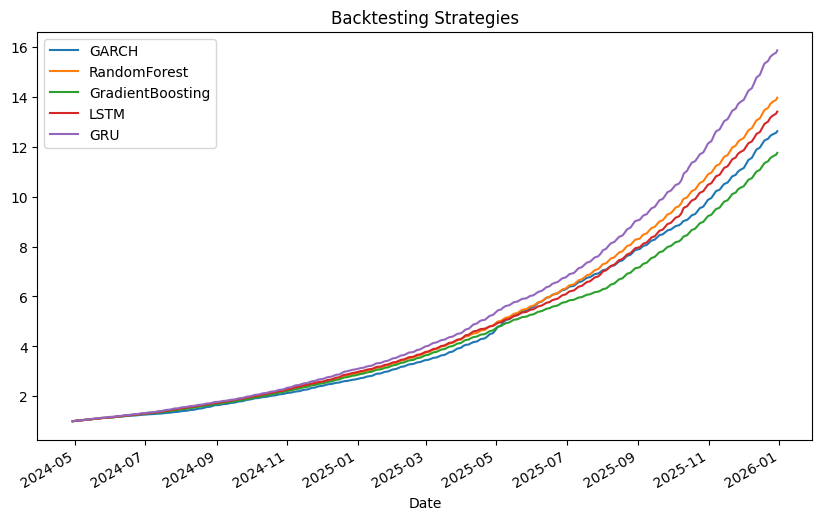

In [21]:
plt.figure(figsize=(10,6))

(1 + strat_garch).cumprod().plot(label="GARCH")
(1 + strat_rf).cumprod().plot(label="RandomForest")
(1 + strat_gb).cumprod().plot(label="GradientBoosting")
(1 + strat_lstm).cumprod().plot(label="LSTM")
(1 + strat_gru).cumprod().plot(label="GRU")

plt.legend()
plt.title("Backtesting Strategies")
plt.show()

Text(0.5, 1.0, 'Drawdown RF Strategy')

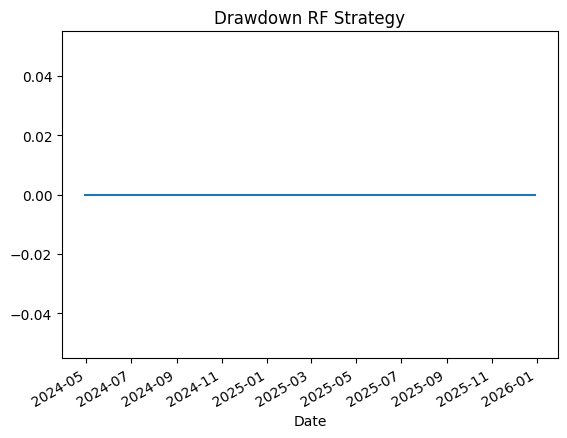

In [22]:
def drawdown(returns):

    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()

    return (cumulative - peak) / peak

drawdown(strat_rf).plot()
plt.title("Drawdown RF Strategy")

In [23]:
from scipy.stats import norm

def compute_var(predicted_vol, alpha=0.05):

    z = norm.ppf(alpha)

    var = z * predicted_vol

    return var

In [24]:
def var_backtest(returns, var):

    violations = returns < var

    violation_rate = violations.mean()

    return violation_rate

In [25]:
var_rf = compute_var(y_pred_rf)
print("VaR RF:", var_rf.mean())

viol_rate_rf = var_backtest(y, var_rf)
print("Violation rate:", viol_rate_rf)

VaR RF: -0.015082149008808039
Violation rate: 0.0


In [28]:
backtest_returns = pd.DataFrame({
    "GARCH": strat_garch,
    "RandomForest": strat_rf,
    "GradientBoosting": strat_gb,
    "LSTM": strat_lstm,
    "GRU": strat_gru

}, index=y.index)

In [29]:
backtest_returns.to_csv("data/processed/backtest_returns.csv")

print(backtest_returns.head())

                              GARCH  RandomForest  GradientBoosting      LSTM  \
Date                                                                            
2024-04-29 04:00:00+00:00  0.006742      0.006703          0.006571  0.006662   
2024-04-30 04:00:00+00:00  0.005591      0.006266          0.006054  0.006642   
2024-05-01 04:00:00+00:00  0.006097      0.006450          0.006265  0.006326   
2024-05-02 04:00:00+00:00  0.006239      0.006375          0.006286  0.006195   
2024-05-03 04:00:00+00:00  0.005969      0.006179          0.006177  0.006240   

                                GRU  
Date                                 
2024-04-29 04:00:00+00:00  0.007352  
2024-04-30 04:00:00+00:00  0.007318  
2024-05-01 04:00:00+00:00  0.007457  
2024-05-02 04:00:00+00:00  0.007367  
2024-05-03 04:00:00+00:00  0.007066  
